Name: HEMA S S
Reg.No: 814724243057
['Colin Powell' 'Donald Rumsfeld' 'George W Bush' 'Gerhard Schroeder'
 'Tony Blair']
(1140, 128, 128, 3)


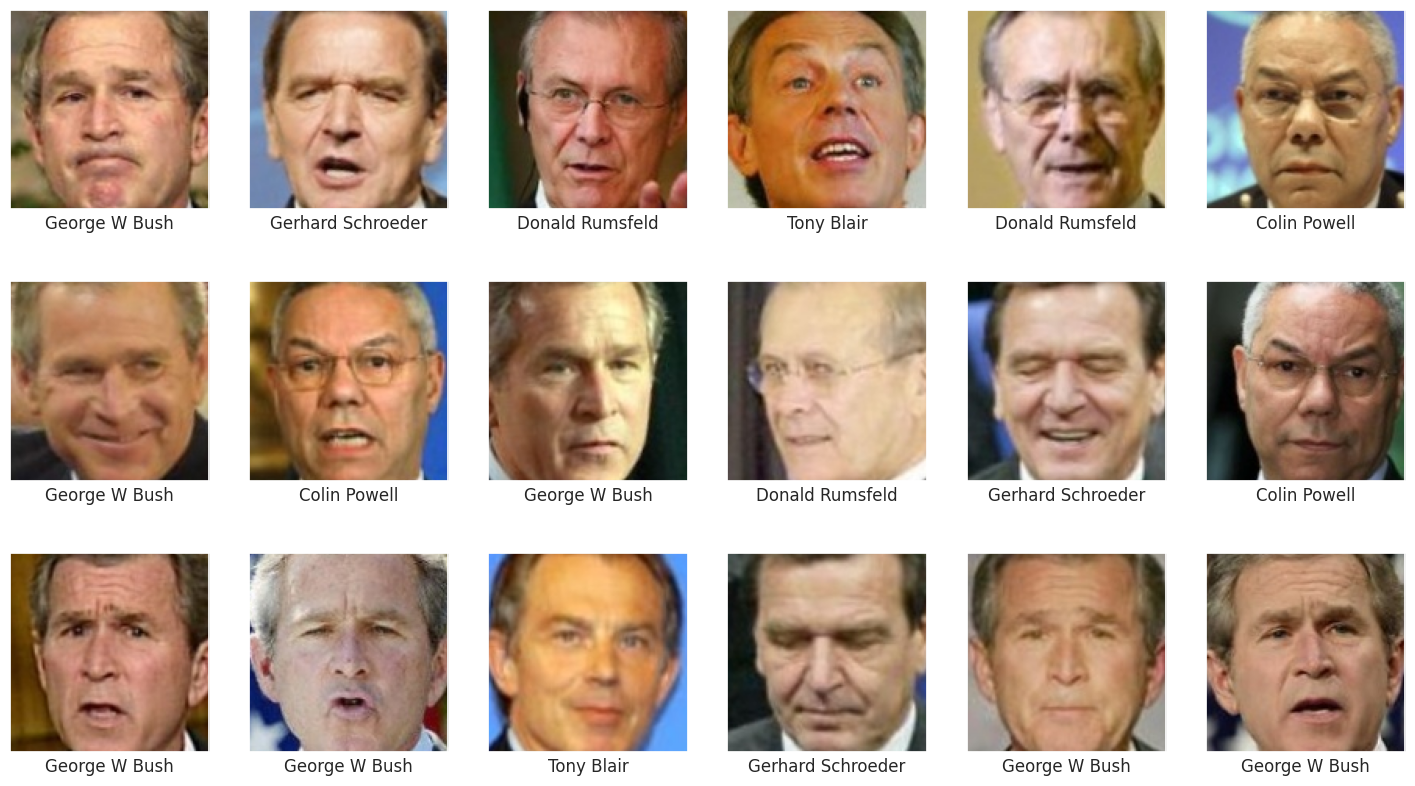

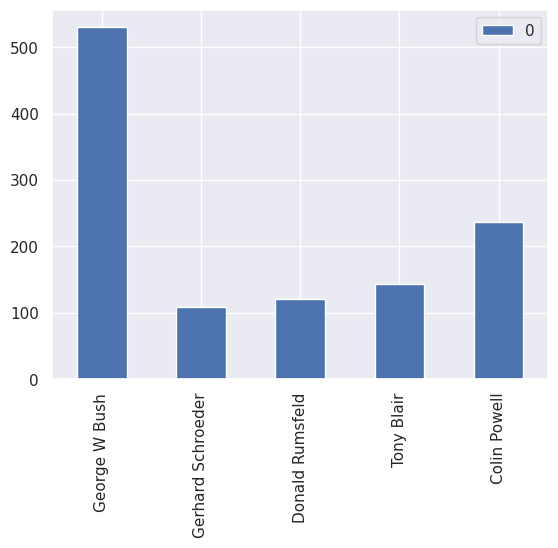

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,662,725 (6.34 MB)

 Trainable params: 1,662,725 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 675ms/step - accuracy: 0.2250 - loss: 1.6286 - val_accuracy: 0.2700 - val_loss: 1.6036
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 614ms/step - accuracy: 0.2750 - loss: 1.5915 - val_accuracy: 0.3300 - val_loss: 1.5873
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 697ms/step - accuracy: 0.3600 - loss: 1.5068 - val_accuracy: 0.2200 - val_loss: 1.5201
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 695ms/step - accuracy: 0.5400 - loss: 1.2431 - val_accuracy: 0.5800 - val_loss: 1.1775
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 656ms/step - accuracy: 0.6500 - loss: 0.9231 - val_accuracy: 0.5500 - val_loss: 1.0882
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 688ms/step - accuracy: 0.7475 - loss: 0.6629 - val_accuracy: 0.6700 - val_loss: 0.8385
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 681ms/step - accuracy: 0.8800 - loss: 0.3463 - val_accuracy: 0.7200 - val_loss: 0.6856
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 597ms/step - accuracy: 0.9300 - loss: 0.2220 - val_accu

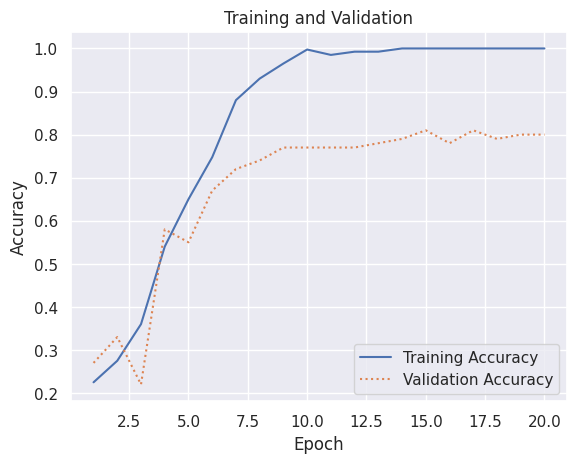

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step


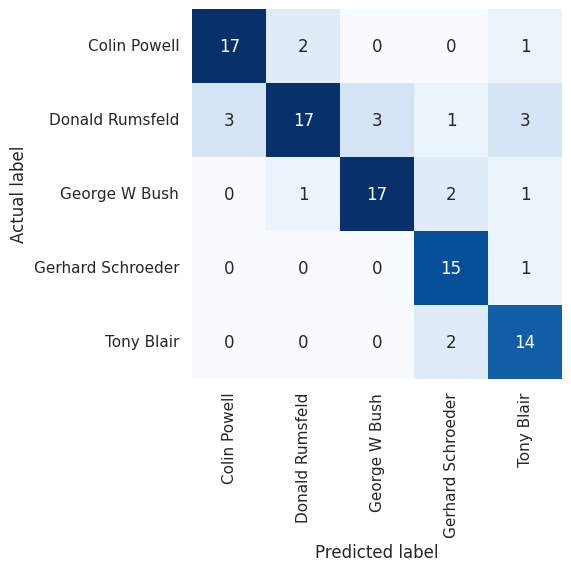

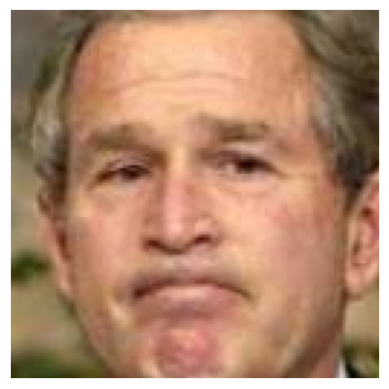

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

--- FINAL PREDICTION RESULTS ---
Colin Powell: 3.8464495e-06
Donald Rumsfeld: 0.0016335784
George W Bush: 0.99831235
Gerhard Schroeder: 4.951233e-08
Tony Blair: 5.024729e-05


In [1]:
# %%
import os
import warnings

# Suppress TensorFlow C++ logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Suppress standard warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_lfw_people
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import tensorflow.keras.utils as image

# Suppress ABSL warnings
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)
print("Name: HEMA S S")
print("Reg.No: 814724243057")
# 1. Fetch Dataset
faces = fetch_lfw_people(min_faces_per_person=100, resize=1.0,
                         slice_=(slice(60,188), slice(60, 188)), color=True)
class_count = len(faces.target_names)

print(faces.target_names)
print(faces.images.shape)

sns.set()

# 2. Visualize initial faces
fig, ax = plt.subplots(3, 6, figsize=(18, 10))
for i, axi in enumerate(ax.flat):
    img = faces.images[i]
    # Dynamically check if normalization is needed so we don't wash out the image to black
    if img.max() > 1.0:
        img = img / 255.0

    axi.imshow(img)
    axi.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[i]])
plt.show()

# 3. Bar Chart
counts = Counter(faces.target)
names = {}
for key in counts.keys():
    names[faces.target_names[key]] = counts[key]

df = pd.DataFrame.from_dict(names, orient='index')
df.plot(kind='bar')
plt.show()

# 4. Filter Dataset
mask = np.zeros(faces.target.shape, dtype=bool)
for target in np.unique(faces.target):
    mask[np.where(faces.target ==target)[0][:100]] = 1

x_faces = faces.data[mask]
y_faces = faces.target[mask]
x_faces = np.reshape(x_faces, (x_faces.shape[0], faces.images.shape[1], faces.images.shape[2], faces.images.shape[3]))

# 5. Preprocess Data
# Apply the same dynamic check to the training data
if x_faces.max() > 1.0:
    face_images = x_faces / 255.0
else:
    face_images = x_faces

face_labels = to_categorical(y_faces)
x_train, x_test, y_train, y_test = train_test_split(face_images, face_labels, train_size=0.8, stratify=face_labels, random_state=0)

# 6. Build Model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(face_images.shape[1:])))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(class_count, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 7. Train Model
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, batch_size=25)

# 8. Plot Accuracy
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, '-', label='Training Accuracy')
plt.plot(epochs, val_acc, ':', label='Validation Accuracy')
plt.title('Training and Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# 9. Confusion Matrix
from sklearn.metrics import confusion_matrix
y_predicted = model.predict(x_test)
mat = confusion_matrix(y_test.argmax(axis=1), y_predicted.argmax(axis=1))

plt.figure()
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=faces.target_names, yticklabels=faces.target_names)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.show()

# 10. External Prediction
george_index = np.where(faces.target == 2)[0][0]
# Ensure the saved image is properly scaled for standard viewing
save_img = faces.images[george_index]
if save_img.max() <= 1.0:
    save_img = (save_img * 255).astype(np.uint8)
plt.imsave('george.jpg', save_img)

try:
    x = image.load_img('george.jpg', target_size=(face_images.shape[1], face_images.shape[2]))
    plt.figure()
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x)
    plt.show()

    # Keras image.img_to_array always returns 0-255, so we safely divide by 255 here
    x = image.img_to_array(x) / 255.0
    x = np.expand_dims(x, axis=0)
    y = model.predict(x)[0]

    print("\n--- FINAL PREDICTION RESULTS ---")
    for i in range(len(y)):
        print(faces.target_names[i] + ': ' + str(y[i]))
except Exception as e:
    print(f"An error occurred during prediction: {e}")